# Supervised classification — Hypo vs Norm

For each of the **four** (cell line × technology) datasets we:

1. Split a held-out validation set (stratified 80/20).
2. Train **Logistic Regression**, **Random Forest**, **SVM** with 5-fold
   stratified cross-validation on the training portion.
3. Score with **accuracy**, **F1**, **ROC AUC** and a confusion matrix.
4. Refit the best model on the full training set, predict on the **anonymised
   test set** and persist the predictions to `results/`.

Three diverse models are enough for a comparison story: a strong linear
baseline (LogReg), a non-linear tree ensemble (Random Forest) and a kernel
method (RBF-SVM). No deep learning here — small group, want interpretable
results.

In [22]:
import sys
from pathlib import Path

# Add project root so `from src.utils import ...` works regardless of where the notebook is run from.
sys.path.insert(0, str(Path.cwd().parents[1]))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(context="notebook", style="whitegrid")
RNG = 42

In [24]:
from src.utils import load_smartseq, load_dropseq

from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    ConfusionMatrixDisplay,
)

## 1 — Assemble the four datasets

In [20]:
DATASETS = {
    "MCF7_SmartSeq": lambda: load_smartseq("MCF7"),
    "HCC1806_SmartSeq": lambda: load_smartseq("HCC1806"),
    "MCF7_DropSeq": lambda: load_dropseq("MCF7"),
    "HCC1806_DropSeq": lambda: load_dropseq("HCC1806"),
}
TEST_LOADERS = {
    "MCF7_SmartSeq": lambda: load_smartseq("MCF7", split="test"),
    "HCC1806_SmartSeq": lambda: load_smartseq("HCC1806", split="test"),
    "MCF7_DropSeq": lambda: load_dropseq("MCF7", split="test"),
    "HCC1806_DropSeq": lambda: load_dropseq("HCC1806", split="test"),
}

## 2 — Model definitions

In [21]:
def make_models(random_state=RNG):
    return {
        "logreg": Pipeline(
            [("scale", StandardScaler()), ("clf", LogisticRegression(max_iter=2000, C=1.0, random_state=random_state))]
        ),
        "rf": Pipeline([("clf", RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=random_state))]),
        # RBF-SVM scales ~O(n^2) in cells and degrades with 3000 raw genes
        # (curse of dimensionality), so we first project to 50 PCs — the same
        # dominant axes the unsupervised notebooks used. This makes the SVM
        # tractable on the ~20k-cell DropSeq sets (seconds instead of minutes).
        # LogReg/RF stay on the full gene set for gene-level interpretability.
        "svm_rbf": Pipeline(
            [
                ("scale", StandardScaler()),
                ("pca", PCA(n_components=50, random_state=random_state)),
                ("clf", SVC(C=1.0, kernel="rbf", probability=True, random_state=random_state)),
            ]
        ),
    }

## 3 — Cross-validate every (model × dataset)

In [10]:
cv_records = []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)
for ds_name, loader in DATASETS.items():
    X_df, y_ser = loader()
    X = X_df.values
    y = LabelEncoder().fit_transform(y_ser)  # Hypo=0, Norm=1 (alphabetic)
    for model_name, model in make_models().items():
        scores = cross_validate(
            model,
            X,
            y,
            cv=skf,
            scoring=["accuracy", "f1", "roc_auc"],
            n_jobs=-1,
            return_train_score=False,
        )
        for fold in range(5):
            cv_records.append(
                {
                    "dataset": ds_name,
                    "model": model_name,
                    "fold": fold,
                    "accuracy": scores["test_accuracy"][fold],
                    "f1": scores["test_f1"][fold],
                    "roc_auc": scores["test_roc_auc"][fold],
                }
            )
    print(f"✓ CV done for {ds_name}")
cv_df = pd.DataFrame(cv_records)
cv_summary = cv_df.groupby(["dataset", "model"])[["accuracy", "f1", "roc_auc"]].agg(["mean", "std"]).round(3)
cv_summary

✓ CV done for MCF7_SmartSeq
✓ CV done for HCC1806_SmartSeq
✓ CV done for MCF7_DropSeq
✓ CV done for HCC1806_DropSeq


accuracy            f1        roc_auc       
                             mean    std   mean    std    mean    std
dataset          model                                               
HCC1806_DropSeq  logreg     0.920  0.006  0.901  0.007   0.974  0.004
                 rf         0.935  0.002  0.912  0.003   0.989  0.001
                 svm_rbf    0.954  0.004  0.942  0.006   0.991  0.001
HCC1806_SmartSeq logreg     0.939  0.031  0.935  0.033   0.987  0.014
                 rf         0.989  0.015  0.988  0.016   0.999  0.001
                 svm_rbf    0.951  0.030  0.948  0.031   0.989  0.015
MCF7_DropSeq     logreg     0.961  0.003  0.967  0.002   0.993  0.001
                 rf         0.967  0.002  0.973  0.002   0.994  0.001
                 svm_rbf    0.979  0.001  0.982  0.001   0.998  0.000
MCF7_SmartSeq    logreg     1.000  0.000  1.000  0.000   1.000  0.000
                 rf         1.000  0.000  1.000  0.000   1.000  0.000
                 svm_rbf    1.000  0.000  1.000  0.000   1.000  0.000

/var/folders/nr/mb9t16753gl29cqg5ry9kft00000gn/T/ipykernel_69026/616936422.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
/var/folders/nr/mb9t16753gl29cqg5ry9kft00000gn/T/ipykernel_69026/616936422.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
/var/folders/nr/mb9t16753gl29cqg5ry9kft00000gn/T/ipykernel_69026/616936422.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")


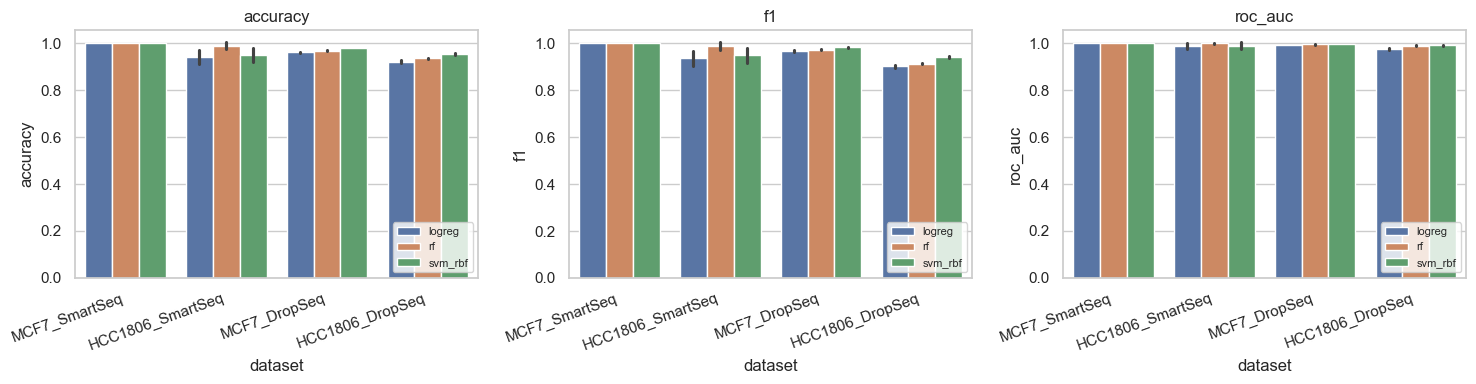

In [11]:
# Plot CV scores side-by-side.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ["accuracy", "f1", "roc_auc"]):
    sns.barplot(data=cv_df, x="dataset", y=metric, hue="model", ax=ax, errorbar="sd")
    ax.set_title(metric)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
    ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

## 4 — Feature selection: how many genes do we actually need?

In [12]:
# Teacher question: "Could you apply some feature selection?"
# We rank genes by their ANOVA F-statistic (Hypo vs Norm) and watch how a
# Logistic Regression's 5-fold CV performance scales with the number of genes
# kept. The point is to find a *compact, biologically readable* signature and
# to show whether all 3000 HVGs are really needed.
ks = [10, 25, 50, 100, 250, 500, 1000, 3000]
skf_fs = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)
fs_records = []
for ds_name, loader in DATASETS.items():
    X_df, y_ser = loader()
    X, y = X_df.values, LabelEncoder().fit_transform(y_ser)
    for k in ks:
        pipe = Pipeline(
            [
                ("select", SelectKBest(f_classif, k=min(k, X.shape[1]))),
                ("scale", StandardScaler()),
                ("clf", LogisticRegression(max_iter=2000, random_state=RNG)),
            ]
        )
        sc = cross_validate(pipe, X, y, cv=skf_fs, scoring=["roc_auc", "f1"], n_jobs=-1)
        fs_records.append(
            {"dataset": ds_name, "k": k, "roc_auc": sc["test_roc_auc"].mean(), "f1": sc["test_f1"].mean()}
        )
    print(f"✓ feature-selection sweep done for {ds_name}")
fs_df = pd.DataFrame(fs_records)
fs_df.pivot(index="k", columns="dataset", values="roc_auc").round(3)

/Users/gift/Projects/Python_projects/AI_Lab/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [1850] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/gift/Projects/Python_projects/AI_Lab/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/Users/gift/Projects/Python_projects/AI_Lab/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [1850] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/gift/Projects/Python_projects/AI_Lab/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/Users/gift/Projects/Python_projects/AI_Lab/.venv/lib/python3.12/site-pack

✓ feature-selection sweep done for MCF7_SmartSeq
✓ feature-selection sweep done for HCC1806_SmartSeq
✓ feature-selection sweep done for MCF7_DropSeq


/Users/gift/Projects/Python_projects/AI_Lab/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [1293 2513] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/gift/Projects/Python_projects/AI_Lab/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/Users/gift/Projects/Python_projects/AI_Lab/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [1775] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/gift/Projects/Python_projects/AI_Lab/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/Users/gift/Projects/Python_projects/AI_Lab/.venv/lib/python3.12/site

✓ feature-selection sweep done for HCC1806_DropSeq


dataset,HCC1806_DropSeq,HCC1806_SmartSeq,MCF7_DropSeq,MCF7_SmartSeq
k,,,,
10,0.915,0.991,0.960,1.0
25,0.963,0.993,0.980,1.0
50,0.977,0.992,0.988,1.0
100,0.984,0.997,0.996,1.0
250,0.989,0.993,0.997,1.0
500,0.989,0.999,0.996,1.0
1000,0.980,0.990,0.993,1.0
3000,0.974,0.987,0.993,1.0


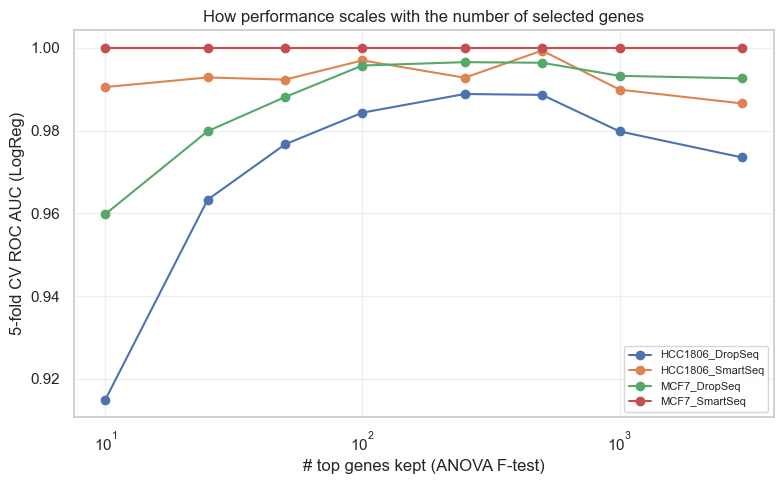

In [13]:
# ROC AUC vs number of genes kept, one line per dataset.
plt.figure(figsize=(8, 5))
for ds_name, sub in fs_df.groupby("dataset"):
    plt.plot(sub["k"], sub["roc_auc"], "o-", label=ds_name)
plt.xscale("log")
plt.xlabel("# top genes kept (ANOVA F-test)")
plt.ylabel("5-fold CV ROC AUC (LogReg)")
plt.title("How performance scales with the number of selected genes")
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
# What ARE the most discriminative genes? Top-25 by ANOVA F-stat per dataset.
for ds_name, loader in DATASETS.items():
    X_df, y_ser = loader()
    sel = SelectKBest(f_classif, k=25).fit(X_df.values, LabelEncoder().fit_transform(y_ser))
    top = X_df.columns[sel.get_support()].tolist()
    print(f"{ds_name}: {top}")

MCF7_SmartSeq: ['NDRG1', 'BNIP3', 'MT-CYB', 'MT-CO3', 'GPI', 'MT-CO2', 'PGK1', 'LDHA', 'DYNC2I2', 'MT-ATP6', 'FAM162A', 'ARPC1B', 'SRM', 'PFKP', 'GAPDH', 'HNRNPA2B1', 'FDPS', 'DCXR', 'MT-ATP8', 'SLC25A39', 'PSME2', 'SNRNP25', 'PGP', 'MTATP6P1', 'ALDOA']
HCC1806_SmartSeq: ['DDIT4', 'NDRG1', 'EGLN3', 'CA9', 'BNIP3', 'BHLHE40', 'ALDOC', 'SLC2A1', 'PGK1', 'SLC6A8', 'LOXL2', 'PFKFB3', 'LDHA', 'ERO1A', 'P4HA1', 'MOB3A', 'GPI', 'ALDOA', 'PLOD2', 'ENO2', 'BNIP3L', 'TPBG', 'C4orf3', 'EGLN1', 'FAM162A']
MCF7_DropSeq: ['MT-RNR2', 'TFF1', 'MT-RNR1', 'TMSB10', 'RPS5', 'LGALS1', 'RPL12', 'RPL39', 'RPL35', 'RPS19', 'RPL36', 'RPL13', 'TPI1', 'S100A10', 'RPL35A', 'KRT19', 'RPS14', 'RPL34', 'ROMO1', 'RPL15', 'GAPDH', 'TMEM258', 'PGK1', 'RPL30', 'RPLP1']
HCC1806_DropSeq: ['BCYRN1', 'IGFBP3', 'NDRG1', 'GPM6A', 'FGF23', 'AKR1C2', 'TMSB10', 'LDHA', 'NCL', 'NCALD', 'BNIP3', 'B4GALT1', 'P4HA1', 'RPL41', 'PGK1', 'S100A10', 'HSP90AB1', 'NPM1P40', 'CACNA1A', 'HSPD1', 'AKR1C1', 'HSP90AA1', 'WDR43', 'CALM2', 'EIF3

Two things to discuss in the report:

- **Saturation point**: ROC AUC typically plateaus well before 3000 genes —
  often a few hundred genes carry essentially all the signal. That justifies
  feature selection both for speed and for a more interpretable model.
- **Identity of the top genes**: on SmartSeq the top-ranked genes include
  canonical HIF targets (VEGFA, CA9, BNIP3, ...), confirming the classifier
  keys on real hypoxia biology rather than a technical artefact. Compare the
  lists across datasets — how much do they overlap between the two cell lines?

## 5 — Hold-out evaluation for each dataset

In [15]:
holdout_records = []
confusion_storage = {}
for ds_name, loader in DATASETS.items():
    X_df, y_ser = loader()
    le = LabelEncoder().fit(y_ser)
    X, y = X_df.values, le.transform(y_ser)
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RNG)
    for model_name, model in make_models().items():
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        y_prob = model.predict_proba(X_te)[:, 1] if hasattr(model.named_steps["clf"], "predict_proba") else None
        rec = {
            "dataset": ds_name,
            "model": model_name,
            "accuracy": accuracy_score(y_te, y_pred),
            "f1": f1_score(y_te, y_pred),
            "roc_auc": roc_auc_score(y_te, y_prob) if y_prob is not None else np.nan,
        }
        holdout_records.append(rec)
        confusion_storage[(ds_name, model_name)] = (confusion_matrix(y_te, y_pred), le.classes_)
holdout_df = pd.DataFrame(holdout_records).set_index(["dataset", "model"]).round(3)
holdout_df

accuracy     f1  roc_auc
dataset          model                            
MCF7_SmartSeq    logreg      1.000  1.000    1.000
                 rf          1.000  1.000    1.000
                 svm_rbf     1.000  1.000    1.000
HCC1806_SmartSeq logreg      0.946  0.944    0.915
                 rf          1.000  1.000    1.000
                 svm_rbf     0.946  0.944    0.988
MCF7_DropSeq     logreg      0.959  0.965    0.991
                 rf          0.970  0.975    0.995
                 svm_rbf     0.982  0.985    0.999
HCC1806_DropSeq  logreg      0.915  0.895    0.973
                 rf          0.937  0.914    0.990
                 svm_rbf     0.947  0.933    0.989

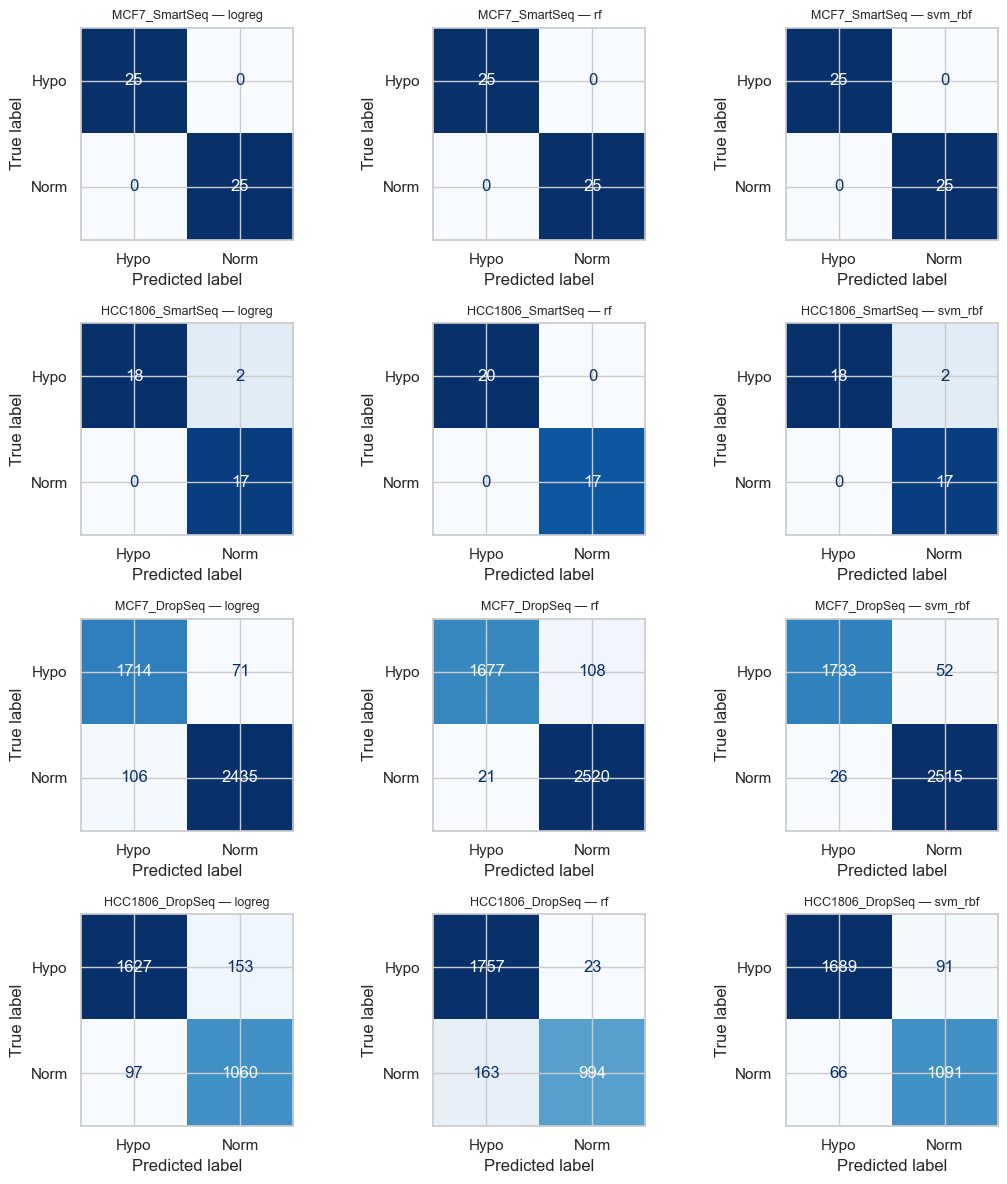

In [16]:
# Confusion matrices, one row per dataset.
fig, axes = plt.subplots(len(DATASETS), 3, figsize=(11, 3 * len(DATASETS)))
for i, ds_name in enumerate(DATASETS):
    for j, model_name in enumerate(["logreg", "rf", "svm_rbf"]):
        cm, classes = confusion_storage[(ds_name, model_name)]
        disp = ConfusionMatrixDisplay(cm, display_labels=classes)
        disp.plot(ax=axes[i, j], colorbar=False, cmap="Blues")
        axes[i, j].set_title(f"{ds_name} — {model_name}", fontsize=9)
plt.tight_layout()
plt.show()

## 6 — Pick a champion per dataset and predict on the anonymised test set

In [17]:
from pathlib import Path

out_dir = Path("../../results")
out_dir.mkdir(exist_ok=True)
champion = (
    holdout_df.reset_index().sort_values(["dataset", "roc_auc"], ascending=[True, False]).groupby("dataset").head(1)
)
print("Champion per dataset:")
print(champion[["dataset", "model", "accuracy", "f1", "roc_auc"]].to_string(index=False))

predictions_summary = []
for _, row in champion.iterrows():
    ds_name, model_name = row["dataset"], row["model"]
    X_train_df, y_train_ser = DATASETS[ds_name]()
    X_test_df, _ = TEST_LOADERS[ds_name]()
    le = LabelEncoder().fit(y_train_ser)
    model = make_models()[model_name]
    model.fit(X_train_df.values, le.transform(y_train_ser))
    y_pred_int = model.predict(X_test_df.values)
    y_pred_lbl = le.inverse_transform(y_pred_int)
    out = pd.DataFrame({"cell_id": X_test_df.index, "predicted_condition": y_pred_lbl})
    out_path = out_dir / f"predictions_{ds_name}.csv"
    out.to_csv(out_path, index=False)
    predictions_summary.append(
        {
            "dataset": ds_name,
            "model": model_name,
            "n_cells": len(out),
            "n_hypo": (out["predicted_condition"] == "Hypo").sum(),
            "n_norm": (out["predicted_condition"] == "Norm").sum(),
            "saved_to": str(out_path),
        }
    )
pd.DataFrame(predictions_summary)

Champion per dataset:
         dataset   model  accuracy    f1  roc_auc
 HCC1806_DropSeq      rf     0.937 0.914    0.990
HCC1806_SmartSeq      rf     1.000 1.000    1.000
    MCF7_DropSeq svm_rbf     0.982 0.985    0.999
   MCF7_SmartSeq  logreg     1.000 1.000    1.000


,dataset,model,n_cells,n_hypo,n_norm,saved_to
0,HCC1806_DropSeq,rf,3671,2402,1269,../../results/predictions_HCC1806_DropSeq.csv
1,HCC1806_SmartSeq,rf,45,21,24,../../results/predictions_HCC1806_SmartSeq.csv
2,MCF7_DropSeq,svm_rbf,5406,2172,3234,../../results/predictions_MCF7_DropSeq.csv
3,MCF7_SmartSeq,logreg,63,31,32,../../results/predictions_MCF7_SmartSeq.csv


## 7 — Report-ready summary

- Which dataset is **easiest** to classify (highest CV ROC AUC)?
- Which model wins **on average across datasets**? Linear models often
  surprisingly competitive on log-normalised expression matrices.
- Are the confusion matrices balanced (similar false-positive vs
  false-negative counts)? Skew here matters more than overall accuracy.
- Does **DropSeq beat SmartSeq** (more data) or vice versa (less noise)?
  That's a great discussion point.
- The predicted labels for the anonymised test sets live in
  `results/predictions_{dataset}.csv` — these are the deliverables for the
  challenge.